**INSTALL FAKER**

In [ ]:
pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 16.0 MB/s eta 0:00:00


In [ ]:
from faker import Faker

In [ ]:
fake = Faker()

**DATA SET**

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = []

for i in range(100000):
    age = np.random.randint(18, 71)
    gender = np.random.choice(["Male", "Female"])
    tenure = np.random.randint(0, 11)
    balance = round(np.random.uniform(0, 200000), 2)
    credit_score = np.random.randint(300, 901)
    salary = round(np.random.uniform(10000, 150000), 2)
    products = np.random.randint(1, 5)
    active = np.random.choice(["Yes", "No"])
    churn = 1 if (balance < 50000 and active == "No") else 0

    data.append([
        i+1, age, gender, tenure, balance,
        credit_score, salary, products, active, churn
    ])

df = pd.DataFrame(data, columns=[
    "Customer_ID", "Age", "Gender", "Tenure", "Balance",
    "CreditScore", "EstimatedSalary", "NumOfProducts",
    "IsActiveMember", "Churn"
])

df.head()

,Customer_ID,Age,Gender,Tenure,Balance,CreditScore,EstimatedSalary,NumOfProducts,IsActiveMember,Churn
0,1,51,Male,2,155725.32,461,131834.75,1,Yes,0
1,2,58,Female,10,967.46,661,95790.38,1,No,1
2,3,48,Male,2,196391.88,573,91782.05,3,No,0
3,4,63,Female,9,121244.75,765,23894.12,2,Yes,0
4,5,55,Male,3,171222.10,346,40790.25,1,Yes,0


In [ ]:
print(df.isnull().sum())
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["IsActiveMember"] = df["IsActiveMember"].map({"Yes": 1, "No": 0})

df.info()

Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Customer_ID      100000 non-null  int64  
 1   Age              100000 non-null  int64  
 2   Gender           100000 non-null  int64  
 3   Tenure           100000 non-null  int64  
 4   Balance          100000 non-null  float64
 5   CreditScore      100000 non-null  int64  
 6   EstimatedSalary  100000 non-null  float64
 7   NumOfProducts    100000 non-null  int64  
 8   IsActiveMember   100000 non-null  int64  
 9   Churn            100000 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 7.6 MB


In [ ]:
print(df.describe())
print("Mean:\n", df.mean())
print("Median:\n", df.median())
print("Standard Deviation:\n", df.std())

         Customer_ID            Age         Gender         Tenure  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean    50000.500000      44.038730       0.500950       4.995090   
std     28867.657797      15.257808       0.500002       3.161153   
min         1.000000      18.000000       0.000000       0.000000   
25%     25000.750000      31.000000       0.000000       2.000000   
50%     50000.500000      44.000000       1.000000       5.000000   
75%     75000.250000      57.000000       1.000000       8.000000   
max    100000.000000      70.000000       1.000000      10.000000   

             Balance    CreditScore  EstimatedSalary  NumOfProducts  \
count  100000.000000  100000.000000    100000.000000  100000.000000   
mean    99688.569601     599.759570     79826.793302       2.496780   
std     57741.232504     173.585356     40468.991930       1.116666   
min         0.620000     300.000000     10000.800000       1.000000   
25%     49590.120000   

In [ ]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
0    87406
1    12594
Name: count, dtype: int64
Churn
0    87.406
1    12.594
Name: proportion, dtype: float64


In [ ]:

print(pd.crosstab(df["Gender"], df["Churn"]))
print(pd.crosstab(df["IsActiveMember"], df["Churn"]))
print(pd.crosstab(df["NumOfProducts"], df["Churn"]))

Churn       0     1
Gender             
0       43497  6408
1       43909  6186
Churn               0      1
IsActiveMember              
0               37255  12594
1               50151      0
Churn              0     1
NumOfProducts             
1              21844  3223
2              21783  3185
3              22048  3137
4              21731  3049


In [ ]:

corr = df.corr()
print(corr)

                 Customer_ID       Age    Gender    Tenure   Balance  \
Customer_ID         1.000000  0.005603 -0.001466 -0.000100  0.001141   
Age                 0.005603  1.000000 -0.001154  0.004014  0.003390   
Gender             -0.001466 -0.001154  1.000000  0.000095  0.001638   
Tenure             -0.000100  0.004014  0.000095  1.000000 -0.003118   
Balance             0.001141  0.003390  0.001638 -0.003118  1.000000   
CreditScore         0.001908  0.003321  0.000090  0.000991 -0.004920   
EstimatedSalary    -0.001338  0.000758 -0.001112 -0.002354  0.001150   
NumOfProducts       0.004551  0.006315 -0.008189 -0.003570  0.004275   
IsActiveMember     -0.001496  0.000061  0.001754 -0.004086 -0.001542   
Churn              -0.000947  0.002586 -0.007412  0.003927 -0.490147   

                 CreditScore  EstimatedSalary  NumOfProducts  IsActiveMember  \
Customer_ID         0.001908        -0.001338       0.004551       -0.001496   
Age                 0.003321         0.000758  

**BAR CHART**

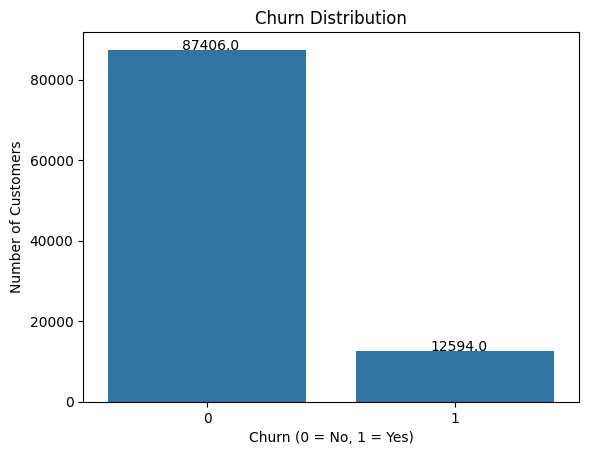

In [21]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
for p in plt.gca().patches:
    plt.gca().annotate(p.get_height(),
                       (p.get_x()+0.3, p.get_height()+100))

plt.show()

**PIE CHART**

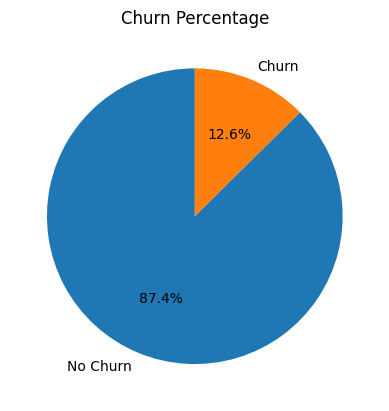

In [22]:
df["Churn"].value_counts().plot.pie(
    autopct="%1.1f%%",
    labels=["No Churn", "Churn"],
    startangle=90
)
plt.title("Churn Percentage")
plt.ylabel("")
plt.show()

**HISTOGRAM**

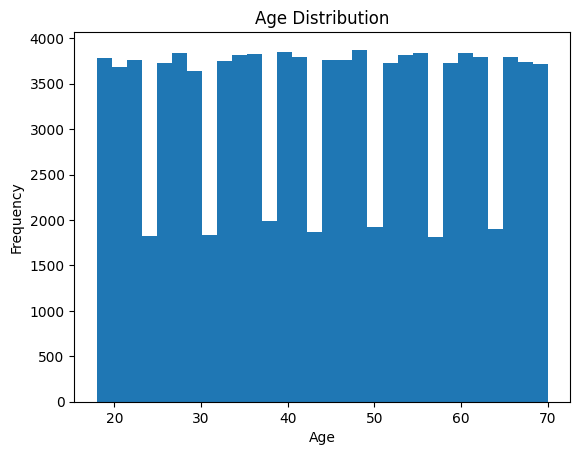

In [23]:
plt.hist(df["Age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**SCATTER PLOT**

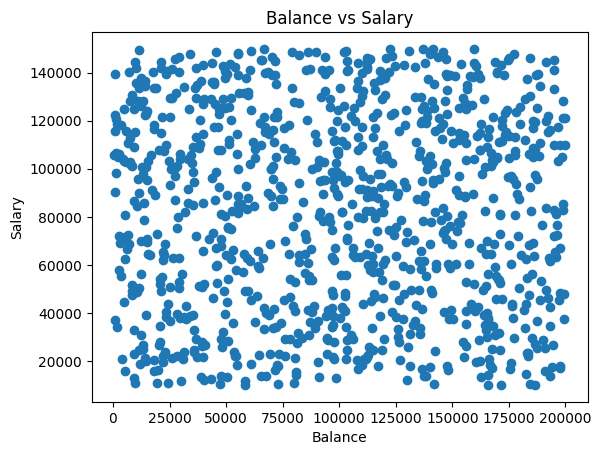

In [25]:
sample_df = df.sample(1000)
plt.scatter(sample_df["Balance"], sample_df["EstimatedSalary"])
plt.title("Balance vs Salary")
plt.xlabel("Balance")
plt.ylabel("Salary")
plt.show()

**BOX PLOT**

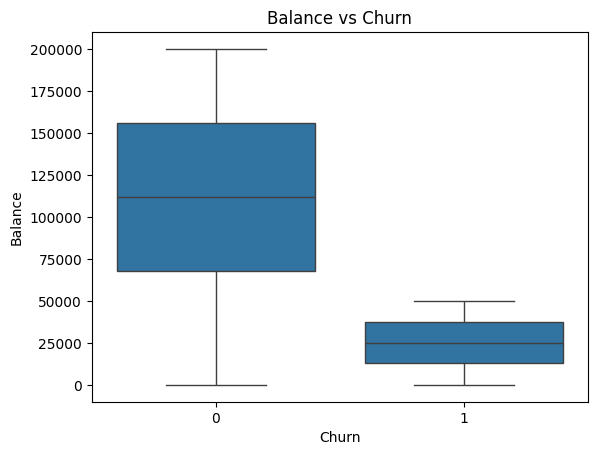

In [26]:
sns.boxplot(x="Churn", y="Balance", data=df)
plt.title("Balance vs Churn")
plt.xlabel("Churn")
plt.ylabel("Balance")
plt.show()

**HEAT MAP**

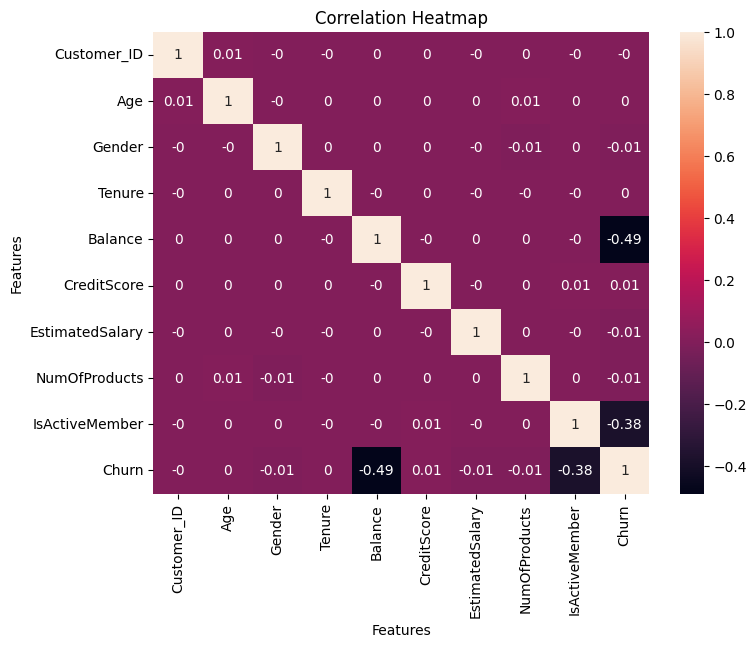

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr().round(2), annot=True)

plt.title("Correlation Heatmap")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

In [29]:
print("Average Balance (Churned):", df[df["Churn"]==1]["Balance"].mean())
print("Average Balance (Not Churned):", df[df["Churn"]==0]["Balance"].mean())
print("Inactive Members Churn Rate:")
print(df[df["IsActiveMember"]==0]["Churn"].mean())

Average Balance (Churned): 25129.79301730983
Average Balance (Not Churned): 110431.46176257925
Inactive Members Churn Rate:
0.25264298180505124
